In [ ]:
import sys, os
sys.path.insert(0, '../../')
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt 
from gasp import load_dataset, process_data_for_gasp, apply_mask_to_data

import logging
logging.getLogger('gasp.dataset').setLevel(logging.DEBUG)
logging.basicConfig() 

In [82]:
ds = {
    'path':'2025_10_1_sphere_phantom',
    'filter':'_fa60_'
}
M = load_dataset(**ds, )

ds_fieldmap = { 
    'path':'2025_10_1_sphere_phantom',
    'filter': 'gre_field_mapping',
    'description': 'GRE field mapping with TE1 = 4.92ms and TE2 = 7.38ms'
}
M_fieldmap = load_dataset(**ds_fieldmap)

ds_dixon = {
    'path':'2025_10_1_sphere_phantom',
    'filter': ['_gre_TE3p41', '_gre_TE4p55', '_gre_TE5p68']
}

M_dixon = load_dataset(**ds_dixon)

print('M shape: ', M.shape)
print('M_fieldmap shape: ', M_fieldmap.shape)
print('M_dixon shape: ', M_dixon.shape)

DEBUG:gasp.dataset:Filter: _fa60_
DEBUG:gasp.dataset:Loading from: /Users/michael/projects/mri/GASP/notebooks/datasets/../../gasp/../data/2025_10_1_sphere_phantom
DEBUG:gasp.dataset:Files: ['meas_MID231_bSSFP_gasp_knee_fa60_TR7ms_FID84860.dat', 'meas_MID232_bSSFP_gasp_knee_fa60_TR14ms_FID84861.dat', 'meas_MID233_bSSFP_gasp_knee_fa60_TR28ms_FID84862.dat']


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


DEBUG:gasp.dataset:Filter: gre_field_mapping                     
DEBUG:gasp.dataset:Loading from: /Users/michael/projects/mri/GASP/notebooks/datasets/../../gasp/../data/2025_10_1_sphere_phantom
DEBUG:gasp.dataset:Files: ['meas_MID247_gre_field_mapping_FID84876.dat']


...

DEBUG:gasp.dataset:Filter: _gre_TE3p41,_gre_TE4p55,_gre_TE5p68
DEBUG:gasp.dataset:Loading from: /Users/michael/projects/mri/GASP/notebooks/datasets/../../gasp/../data/2025_10_1_sphere_phantom
DEBUG:gasp.dataset:Files: ['meas_MID242_gre_TE3p41_FID84871.dat', 'meas_MID243_gre_TE4p55_FID84872.dat', 'meas_MID244_gre_TE5p68_FID84873.dat']


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


M shape:  (256, 256, 8, 16, 3)
M_fieldmap shape:  (128, 128, 8, 2, 1)
M_dixon shape:  (64, 64, 8, 3)


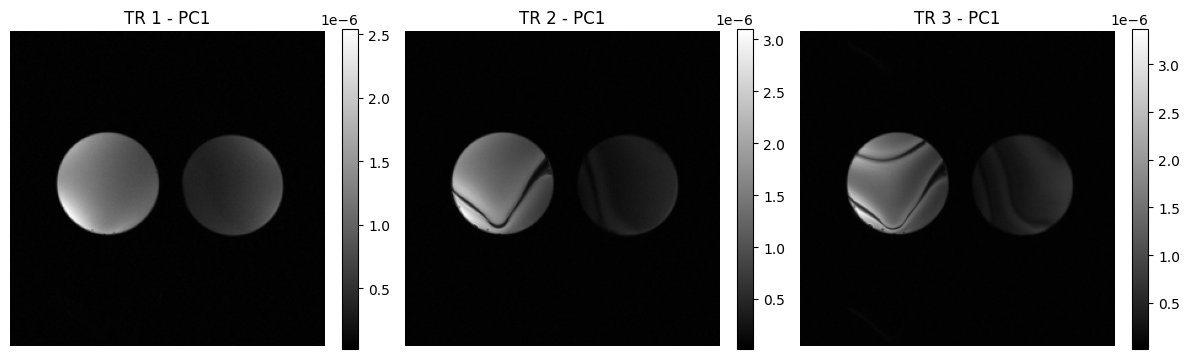

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# M shape: (Height, Width, Coil, PCs, TRs)
# Combine coils using root sum of squares (optimal for magnitude)
M_rss = np.sqrt(np.sum(np.abs(M)**2, axis=2))  # shape: (H, W, PCs, TRs)

# Extract first PC (index 0) for all 3 TRs
first_pc = M_rss[:, :, 0, :]  # shape: (H, W, TRs)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    im = axes[i].imshow(np.abs(first_pc[:, :, i]), cmap='gray')
    axes[i].set_title(f'TR {i+1} - PC1')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)
plt.tight_layout()
plt.show()

Original fieldmap shape: (128, 128)
Interpolated fieldmap shape: (256, 256)
Fieldmap range: -300.0 to 283.7 Hz


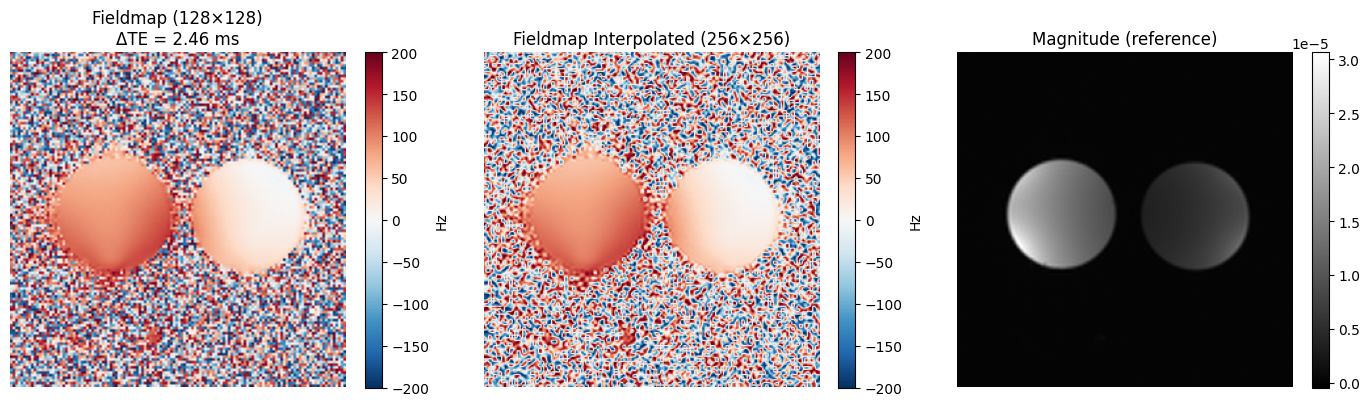

In [84]:
from scipy.ndimage import zoom

# M_fieldmap shape: (128, 128, 8, 2, 1) - (H, W, Coils, Echoes, TRs)
# TE1 = 4.92ms, TE2 = 7.38ms
TE1 = 4.92e-3  # seconds
TE2 = 7.38e-3  # seconds
delta_TE = TE2 - TE1  # 2.46 ms

# Combine coils using root sum of squares for magnitude-weighted phase
M_fm_te1 = M_fieldmap[:, :, :, 0, 0]  # (128, 128, 8)
M_fm_te2 = M_fieldmap[:, :, :, 1, 0]  # (128, 128, 8)

# Coil-combined phase difference (magnitude-weighted)
# Weight by magnitude to reduce noise in low-signal regions
magnitude = np.sqrt(np.sum(np.abs(M_fm_te1)**2 + np.abs(M_fm_te2)**2, axis=2))
phase_diff_per_coil = np.angle(M_fm_te2 * np.conj(M_fm_te1))

# Weighted average of phase difference across coils
weights = np.abs(M_fm_te1) * np.abs(M_fm_te2)
phase_diff = np.angle(np.sum(M_fm_te2 * np.conj(M_fm_te1), axis=2))

# Convert phase difference to Hz
fieldmap_hz = phase_diff / (2 * np.pi * delta_TE)

# Interpolate to match M dimensions (256, 256)
target_shape = M.shape[:2]  # (256, 256)
zoom_factors = (target_shape[0] / fieldmap_hz.shape[0], 
                target_shape[1] / fieldmap_hz.shape[1])
fieldmap_hz_interp = zoom(fieldmap_hz, zoom_factors, order=3)

print(f"Original fieldmap shape: {fieldmap_hz.shape}")
print(f"Interpolated fieldmap shape: {fieldmap_hz_interp.shape}")
print(f"Fieldmap range: {fieldmap_hz_interp.min():.1f} to {fieldmap_hz_interp.max():.1f} Hz")

# Plot original and interpolated fieldmaps
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(fieldmap_hz, cmap='RdBu_r', vmin=-200, vmax=200)
axes[0].set_title(f'Fieldmap (128×128)\nΔTE = {delta_TE*1e3:.2f} ms')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], label='Hz', fraction=0.046)

im1 = axes[1].imshow(fieldmap_hz_interp, cmap='RdBu_r', vmin=-200, vmax=200)
axes[1].set_title(f'Fieldmap Interpolated (256×256)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], label='Hz', fraction=0.046)

# Show magnitude for reference
im2 = axes[2].imshow(zoom(magnitude, zoom_factors, order=3), cmap='gray')
axes[2].set_title('Magnitude (reference)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

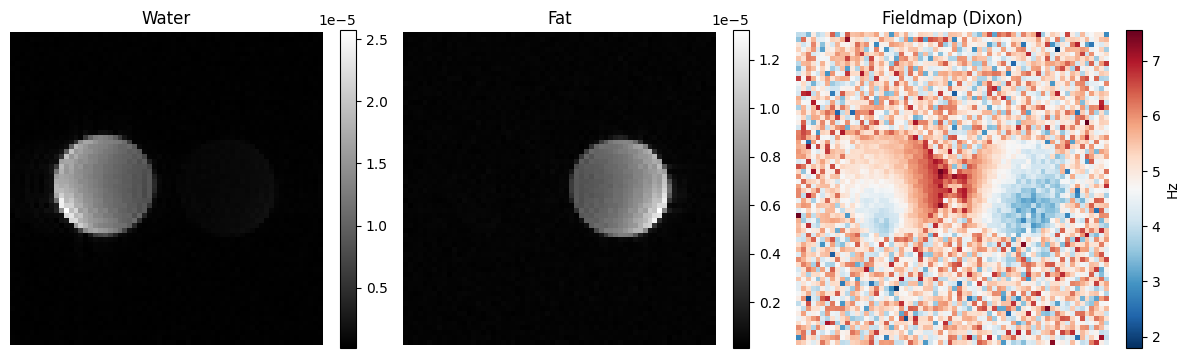

In [85]:
from gasp.analysis import dixon_3pt

Mwater, Mfat, field_map = dixon_3pt(M_dixon)

# Flip horizontally so water is on the left side
Mwater = np.fliplr(Mwater.T)
Mfat = np.fliplr(Mfat.T)
field_map = np.fliplr(field_map.T)

# Plot water, fat, and fieldmap in 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(Mwater, cmap='gray')
axes[0].set_title('Water')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(Mfat, cmap='gray')
axes[1].set_title('Fat')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(field_map, cmap='RdBu_r')
axes[2].set_title('Fieldmap (Dixon)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], label='Hz', fraction=0.046)

plt.tight_layout()
plt.show()

Water profile shift: -0.25
Fat profile shift: +0.25
Profile width: 256
Water profile shape: (256,)
Fat profile shape: (256,)


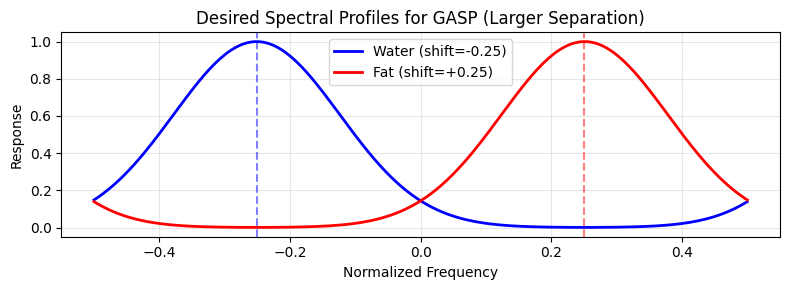

In [86]:
# Normal GASP Water/Fat Separation (without fieldmap compensation)
from gasp import responses
from gasp.gasp import train_gasp_with_coils

# Acquisition parameters for _fa60_ data
TRs = np.array([7e-3, 14e-3, 28e-3])  # 7ms, 14ms, 28ms
TEs = TRs / 2  # Assume TE = TR/2 for bSSFP
alpha = np.deg2rad(60)  # 60 degree flip angle
npcs = 16  # Number of phase cycles
pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)

# Create spectral profiles for water and fat with larger separation
# shift = -0.25 for water (one quarter left), shift = +0.25 for fat (one quarter right)
# Profile width should match the image width (spatial dimension)
profile_width = M.shape[1]  # 256

D_water = responses.bandpass(profile_width, bw=0.3, shift=-0.25, type='gaussian')
D_fat = responses.bandpass(profile_width, bw=0.3, shift=0.25, type='gaussian')

print(f"Water profile shift: -0.25")
print(f"Fat profile shift: +0.25")
print(f"Profile width: {profile_width}")
print(f"Water profile shape: {D_water.shape}")
print(f"Fat profile shape: {D_fat.shape}")

# Plot the spectral profiles
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
freq_axis = np.linspace(-0.5, 0.5, profile_width)
ax.plot(freq_axis, D_water, 'b-', label='Water (shift=-0.25)', linewidth=2)
ax.plot(freq_axis, D_fat, 'r-', label='Fat (shift=+0.25)', linewidth=2)
ax.set_xlabel('Normalized Frequency')
ax.set_ylabel('Response')
ax.set_title('Desired Spectral Profiles for GASP (Larger Separation)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axvline(-0.25, color='b', linestyle='--', alpha=0.5)
ax.axvline(0.25, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Using all TRs: [ 7. 14. 28.] ms
Full data shape: (256, 256, 8, 16, 3)
Foreground pixels: 10802 / 65536 (16.5%)

Training GASP for water...
Training GASP for fat...

GASP water shape: (256, 256)
GASP fat shape: (256, 256)


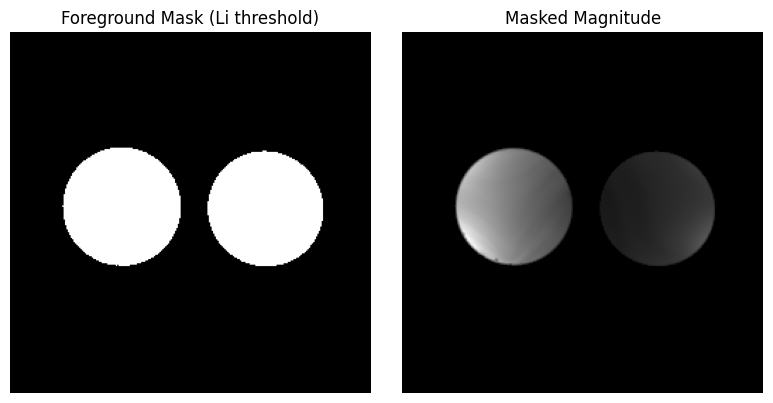

In [99]:
# Apply normal GASP to real data using all TRs
# M shape: (256, 256, 8, 16, 3) - (H, W, Coils, PCs, TRs)
from gasp.gasp import process_data_for_gasp, create_data_mask, apply_mask_to_data

print(f"Using all TRs: {TRs*1e3} ms")
print(f"Full data shape: {M.shape}")

# Preprocess data: mask out background noise
M_masked = process_data_for_gasp(M, useMask=True)
mask = create_data_mask(M)
print(f"Foreground pixels: {np.sum(mask)} / {mask.size} ({100*np.sum(mask)/mask.size:.1f}%)")

# Apply GASP for water (uses all TRs)
print("\nTraining GASP for water...")
water_gasp, A_water = train_gasp_with_coils(
    data=M_masked,
    D=D_water,
    method='affine',
    useL2=True,
    lam=1e-2
)

# Apply GASP for fat (uses all TRs)
print("Training GASP for fat...")
fat_gasp, A_fat = train_gasp_with_coils(
    data=M_masked,
    D=D_fat,
    method='affine',
    useL2=True,
    lam=1e-2
)

# Apply mask to outputs
#water_gasp = apply_mask_to_data(water_gasp, mask)
#fat_gasp = apply_mask_to_data(fat_gasp, mask)

print(f"\nGASP water shape: {water_gasp.shape}")
print(f"GASP fat shape: {fat_gasp.shape}")

# Show the mask
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Foreground Mask (Li threshold)')
axes[0].axis('off')

# Show masked magnitude
M_mag = np.sqrt(np.sum(np.abs(M_masked)**2, axis=(2,3,4)))
axes[1].imshow(M_mag, cmap='gray')
axes[1].set_title('Masked Magnitude')
axes[1].axis('off')
plt.tight_layout()
plt.show()

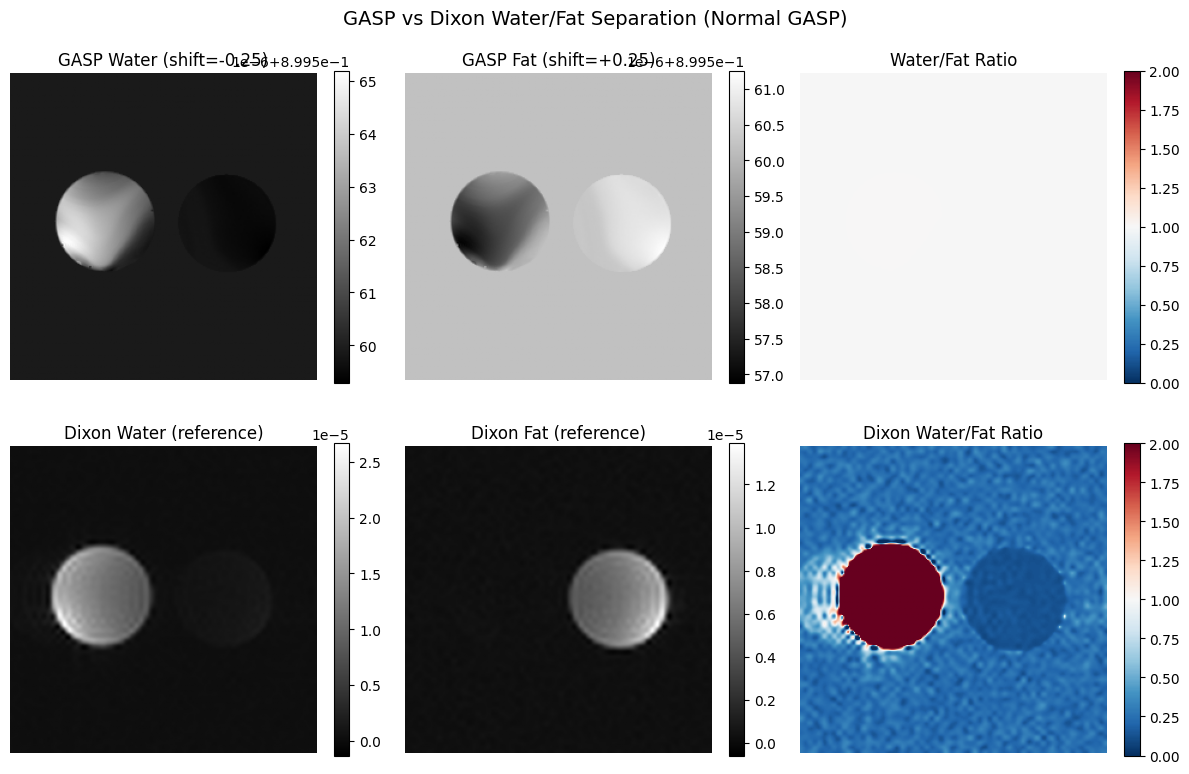

In [100]:
# Plot GASP results vs Dixon results
from scipy.ndimage import zoom

H, W = M.shape[:2]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# GASP results (top row)
im0 = axes[0, 0].imshow(water_gasp, cmap='gray')
axes[0, 0].set_title('GASP Water (shift=-0.25)')
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(fat_gasp, cmap='gray')
axes[0, 1].set_title('GASP Fat (shift=+0.25)')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# Water-Fat ratio
ratio = water_gasp / (fat_gasp + 1e-6)
im2 = axes[0, 2].imshow(ratio, cmap='RdBu_r', vmin=0, vmax=2)
axes[0, 2].set_title('Water/Fat Ratio')
axes[0, 2].axis('off')
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

# Dixon results (bottom row) - interpolate to match GASP dimensions
water_dixon_interp = zoom(Mwater, (H / Mwater.shape[0], W / Mwater.shape[1]), order=3)
fat_dixon_interp = zoom(Mfat, (H / Mfat.shape[0], W / Mfat.shape[1]), order=3)

im3 = axes[1, 0].imshow(water_dixon_interp, cmap='gray')
axes[1, 0].set_title('Dixon Water (reference)')
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

im4 = axes[1, 1].imshow(fat_dixon_interp, cmap='gray')
axes[1, 1].set_title('Dixon Fat (reference)')
axes[1, 1].axis('off')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)

# Dixon Water-Fat ratio
dixon_ratio = water_dixon_interp / (fat_dixon_interp + 1e-6)
im5 = axes[1, 2].imshow(dixon_ratio, cmap='RdBu_r', vmin=0, vmax=2)
axes[1, 2].set_title('Dixon Water/Fat Ratio')
axes[1, 2].axis('off')
plt.colorbar(im5, ax=axes[1, 2], fraction=0.046)

plt.suptitle('GASP vs Dixon Water/Fat Separation (Normal GASP)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# PLANET: Estimate T1 and T2 from phase-cycled bSSFP data
# Using gasp.compensated.estimate_t1_t2_planet()
from gasp.compensated import estimate_t1_t2_planet

# PLANET uses a single TR - use TR=14ms (middle value)
TR_idx = 1
M_tr14 = M[:, :, :, :, TR_idx]  # (256, 256, 8, 16)

# Need to combine coils first - use complex sum for phase preservation
M_tr14_combined = np.sum(M_tr14, axis=2)  # (256, 256, 16)

print("Applying PLANET algorithm to estimate T1 and T2...")
print(f"  Using TR = {TRs[TR_idx]*1e3:.1f} ms for PLANET")
print(f"  Data shape: {M_tr14_combined.shape}")
print(f"  Flip angle = {np.rad2deg(alpha):.0f} degrees")
print(f"  Number of phase cycles = {npcs}")

T1_map, T2_map, f0_map = estimate_t1_t2_planet(
    signals=M_tr14_combined,
    TR=TRs[TR_idx],
    alpha=alpha,
    npcs=npcs,
    T1_guess=1.0  # Initial T1 guess in seconds
)

print(f"\nT1 range: {T1_map[T1_map > 0.05].min():.3f} - {T1_map.max():.3f} s")
print(f"T2 range: {T2_map[T2_map > 0.001].min():.4f} - {T2_map.max():.3f} s")
print(f"f0 range: {f0_map.min():.1f} - {f0_map.max():.1f} Hz")

Applying PLANET algorithm to estimate T1 and T2...
  Using TR = 14.0 ms for PLANET
  Data shape: (256, 256, 2)
  Flip angle = 60 degrees
  Number of phase cycles = 16


ValueError: cannot reshape array of size 131072 into shape (65536,16)

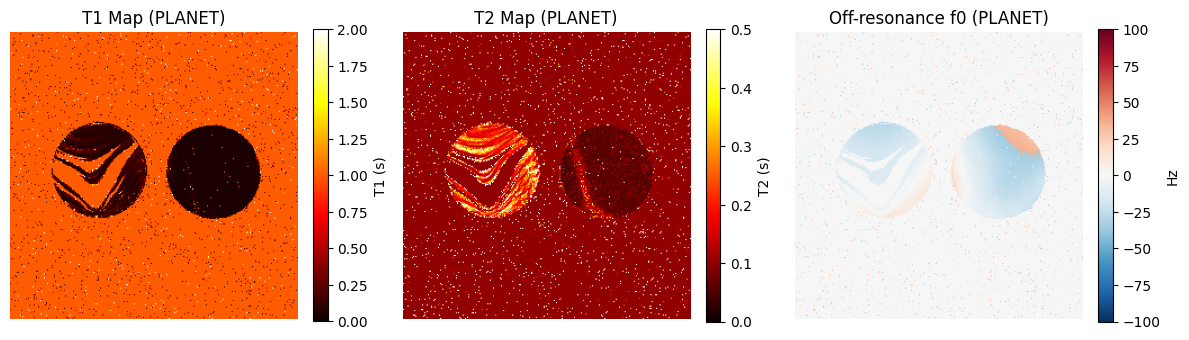

In [112]:
# Plot T1, T2, and f0 maps from PLANET
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# T1 map
im0 = axes[0].imshow(T1_map, cmap='hot', vmin=0, vmax=2)
axes[0].set_title('T1 Map (PLANET)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], label='T1 (s)', fraction=0.046)

# T2 map  
im1 = axes[1].imshow(T2_map, cmap='hot', vmin=0, vmax=0.5)
axes[1].set_title('T2 Map (PLANET)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], label='T2 (s)', fraction=0.046)

# f0 (off-resonance) map
im2 = axes[2].imshow(f0_map, cmap='RdBu_r', vmin=-100, vmax=100)
axes[2].set_title('Off-resonance f0 (PLANET)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], label='Hz', fraction=0.046)

plt.tight_layout()
plt.show()

In [91]:
# Create segmentation masks for water and fat regions
# Use the GASP water/fat images to create masks via thresholding and connected components

from scipy import ndimage
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.morphology import binary_erosion, disk

# Create a combined magnitude image for overall mask
M_rss_mean = np.mean(M_rss[:, :, :, TR_idx], axis=-1)  # Average over phase cycles

# Create water and fat masks based on GASP results
# Normalize images
water_norm = water_gasp / water_gasp.max()
fat_norm = fat_gasp / fat_gasp.max()

# Threshold to identify dominant regions
water_thresh = threshold_otsu(water_norm[water_norm > 0.1])
fat_thresh = threshold_otsu(fat_norm[fat_norm > 0.1])

# Create binary masks
water_mask_raw = water_norm > water_thresh
fat_mask_raw = fat_norm > fat_thresh

# Label connected components
water_labels = label(water_mask_raw)
fat_labels = label(fat_mask_raw)

# Get properties of regions
water_regions = regionprops(water_labels)
fat_regions = regionprops(fat_labels)

print(f"Found {len(water_regions)} water region(s)")
print(f"Found {len(fat_regions)} fat region(s)")

# Select the largest circular regions (the phantoms)
# Sort by area and keep the largest one(s)
if len(water_regions) > 0:
    water_regions = sorted(water_regions, key=lambda r: r.area, reverse=True)
    largest_water = water_regions[0]
    water_mask = water_labels == largest_water.label
else:
    water_mask = water_mask_raw

if len(fat_regions) > 0:
    fat_regions = sorted(fat_regions, key=lambda r: r.area, reverse=True)
    largest_fat = fat_regions[0]
    fat_mask = fat_labels == largest_fat.label
else:
    fat_mask = fat_mask_raw

# Erode masks slightly to avoid edge effects
water_mask_eroded = binary_erosion(water_mask, disk(3))
fat_mask_eroded = binary_erosion(fat_mask, disk(3))

# Ensure no overlap between masks
# Where both are True, assign to the one with higher relative intensity
overlap = water_mask_eroded & fat_mask_eroded
if np.any(overlap):
    water_stronger = water_norm > fat_norm
    water_mask_eroded[overlap & ~water_stronger] = False
    fat_mask_eroded[overlap & water_stronger] = False

print(f"\nWater mask pixels: {np.sum(water_mask_eroded)}")
print(f"Fat mask pixels: {np.sum(fat_mask_eroded)}")

Found 1 water region(s)
Found 22 fat region(s)

Water mask pixels: 3781
Fat mask pixels: 4565


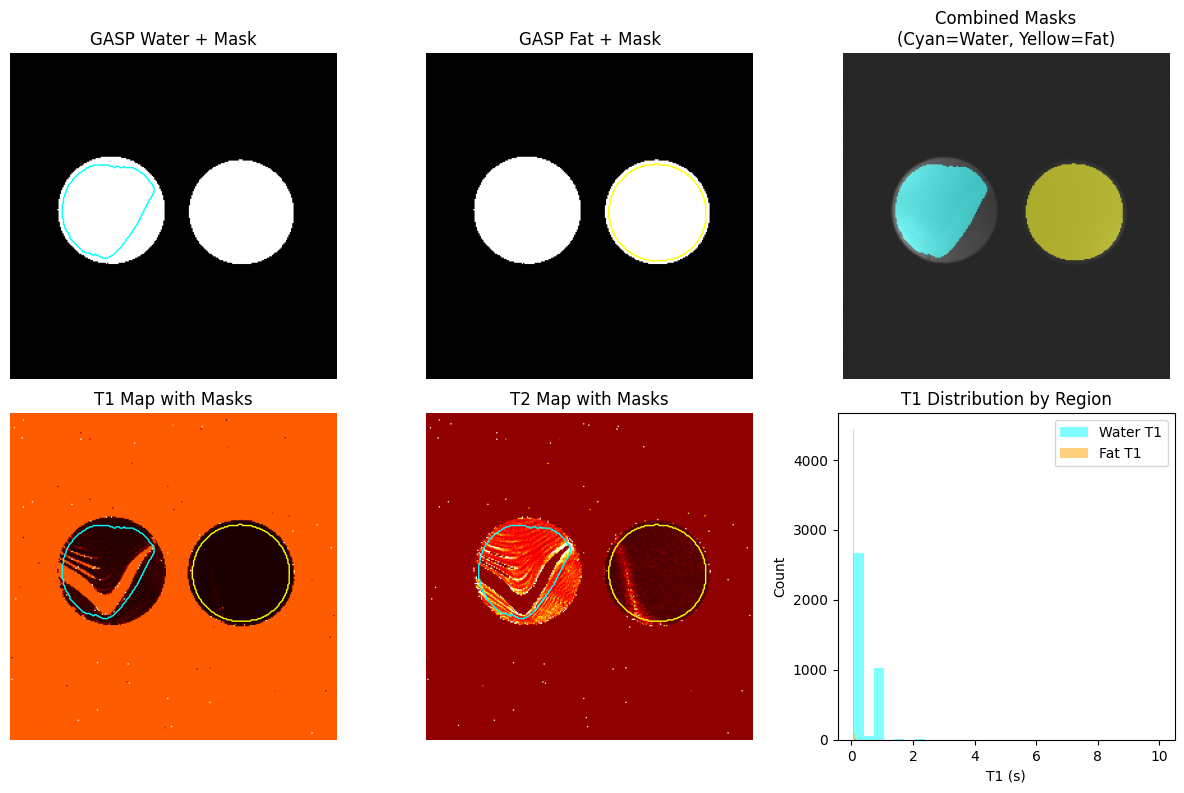

In [92]:
# Visualize segmentation masks
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Top row: Raw masks and GASP images
axes[0, 0].imshow(water_gasp, cmap='gray')
axes[0, 0].contour(water_mask_eroded, colors='cyan', linewidths=1)
axes[0, 0].set_title('GASP Water + Mask')
axes[0, 0].axis('off')

axes[0, 1].imshow(fat_gasp, cmap='gray')
axes[0, 1].contour(fat_mask_eroded, colors='yellow', linewidths=1)
axes[0, 1].set_title('GASP Fat + Mask')
axes[0, 1].axis('off')

# Combined mask visualization
combined_mask = np.zeros((H, W, 3))
combined_mask[water_mask_eroded, 0] = 0  # R
combined_mask[water_mask_eroded, 1] = 1  # G - Water in green
combined_mask[water_mask_eroded, 2] = 1  # B
combined_mask[fat_mask_eroded, 0] = 1    # R - Fat in yellow
combined_mask[fat_mask_eroded, 1] = 1    # G
combined_mask[fat_mask_eroded, 2] = 0    # B

axes[0, 2].imshow(M_rss_mean, cmap='gray', alpha=0.7)
axes[0, 2].imshow(combined_mask, alpha=0.5)
axes[0, 2].set_title('Combined Masks\n(Cyan=Water, Yellow=Fat)')
axes[0, 2].axis('off')

# Bottom row: T1 and T2 maps with masks
axes[1, 0].imshow(T1_map, cmap='hot', vmin=0, vmax=2)
axes[1, 0].contour(water_mask_eroded, colors='cyan', linewidths=1)
axes[1, 0].contour(fat_mask_eroded, colors='yellow', linewidths=1)
axes[1, 0].set_title('T1 Map with Masks')
axes[1, 0].axis('off')

axes[1, 1].imshow(T2_map, cmap='hot', vmin=0, vmax=0.5)
axes[1, 1].contour(water_mask_eroded, colors='cyan', linewidths=1)
axes[1, 1].contour(fat_mask_eroded, colors='yellow', linewidths=1)
axes[1, 1].set_title('T2 Map with Masks')
axes[1, 1].axis('off')

# Histogram of T1/T2 values in each region
axes[1, 2].hist(T1_map[water_mask_eroded].flatten(), bins=30, alpha=0.5, label='Water T1', color='cyan')
axes[1, 2].hist(T1_map[fat_mask_eroded].flatten(), bins=30, alpha=0.5, label='Fat T1', color='orange')
axes[1, 2].set_xlabel('T1 (s)')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('T1 Distribution by Region')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [93]:
# Extract average T1 and T2 values for water and fat regions
# Filter out zero values (background)

# Water region statistics
water_T1_values = T1_map[water_mask_eroded & (T1_map > 0)]
water_T2_values = T2_map[water_mask_eroded & (T2_map > 0)]

# Fat region statistics  
fat_T1_values = T1_map[fat_mask_eroded & (T1_map > 0)]
fat_T2_values = T2_map[fat_mask_eroded & (T2_map > 0)]

# Calculate statistics
water_T1_mean = np.mean(water_T1_values) if len(water_T1_values) > 0 else 0
water_T1_std = np.std(water_T1_values) if len(water_T1_values) > 0 else 0
water_T2_mean = np.mean(water_T2_values) if len(water_T2_values) > 0 else 0
water_T2_std = np.std(water_T2_values) if len(water_T2_values) > 0 else 0

fat_T1_mean = np.mean(fat_T1_values) if len(fat_T1_values) > 0 else 0
fat_T1_std = np.std(fat_T1_values) if len(fat_T1_values) > 0 else 0
fat_T2_mean = np.mean(fat_T2_values) if len(fat_T2_values) > 0 else 0
fat_T2_std = np.std(fat_T2_values) if len(fat_T2_values) > 0 else 0

print("=" * 50)
print("PLANET T1/T2 Estimation Results")
print("=" * 50)
print(f"\nWATER REGION:")
print(f"  T1 = {water_T1_mean*1e3:.1f} +/- {water_T1_std*1e3:.1f} ms")
print(f"  T2 = {water_T2_mean*1e3:.1f} +/- {water_T2_std*1e3:.1f} ms")
print(f"  T1/T2 ratio = {water_T1_mean/water_T2_mean:.2f}" if water_T2_mean > 0 else "  T1/T2 ratio = N/A")

print(f"\nFAT REGION:")
print(f"  T1 = {fat_T1_mean*1e3:.1f} +/- {fat_T1_std*1e3:.1f} ms")
print(f"  T2 = {fat_T2_mean*1e3:.1f} +/- {fat_T2_std*1e3:.1f} ms")
print(f"  T1/T2 ratio = {fat_T1_mean/fat_T2_mean:.2f}" if fat_T2_mean > 0 else "  T1/T2 ratio = N/A")

# Store estimated parameters for training
estimated_params = {
    'water': {
        'T1': water_T1_mean,
        'T1_std': water_T1_std,
        'T2': water_T2_mean,
        'T2_std': water_T2_std,
        'mask': water_mask_eroded
    },
    'fat': {
        'T1': fat_T1_mean,
        'T1_std': fat_T1_std,
        'T2': fat_T2_mean,
        'T2_std': fat_T2_std,
        'mask': fat_mask_eroded
    }
}

print("\n" + "=" * 50)
print("Parameters stored in 'estimated_params' dictionary")

PLANET T1/T2 Estimation Results

WATER REGION:
  T1 = 392.9 +/- 510.0 ms
  T2 = 248.4 +/- 403.8 ms
  T1/T2 ratio = 1.58

FAT REGION:
  T1 = 53.8 +/- 19.6 ms
  T2 = 66.0 +/- 32.2 ms
  T1/T2 ratio = 0.81

Parameters stored in 'estimated_params' dictionary


In [94]:
# Training Setup: Use estimated T1/T2 parameters for GASP model training
# This section prepares training data using the PLANET-estimated parameters

from gasp import ssfp

# Use the estimated T1/T2 values for simulation-based training
print("Training Configuration")
print("=" * 50)

# Training parameters (using estimated values)
train_T1_water = estimated_params['water']['T1']
train_T2_water = estimated_params['water']['T2']
train_T1_fat = estimated_params['fat']['T1']
train_T2_fat = estimated_params['fat']['T2']

print(f"\nUsing estimated parameters for training:")
print(f"  Water: T1={train_T1_water*1e3:.1f}ms, T2={train_T2_water*1e3:.1f}ms")
print(f"  Fat:   T1={train_T1_fat*1e3:.1f}ms, T2={train_T2_fat*1e3:.1f}ms")

# Acquisition parameters
train_TR = TRs[TR_idx]  # 14ms
train_TE = train_TR / 2
train_alpha = alpha
train_pcs = pcs

print(f"\nAcquisition parameters:")
print(f"  TR = {train_TR*1e3:.1f} ms")
print(f"  TE = {train_TE*1e3:.1f} ms")
print(f"  Flip angle = {np.rad2deg(train_alpha):.0f} degrees")
print(f"  Phase cycles = {len(train_pcs)}")

# Target spectral profiles
print(f"\nTarget profiles:")
print(f"  Water: shift=-0.25, bw=0.3")
print(f"  Fat:   shift=+0.25, bw=0.3")

Training Configuration

Using estimated parameters for training:
  Water: T1=392.9ms, T2=248.4ms
  Fat:   T1=53.8ms, T2=66.0ms

Acquisition parameters:
  TR = 14.0 ms
  TE = 7.0 ms
  Flip angle = 60 degrees
  Phase cycles = 16

Target profiles:
  Water: shift=-0.25, bw=0.3
  Fat:   shift=+0.25, bw=0.3


In [95]:
# Simulate bSSFP signals using estimated T1/T2 for training data generation
# This creates a 1D spectral sweep to train GASP coefficients

from gasp.gasp import train_gasp

# Create a spectral sweep (simulating off-resonance variation)
# Use same width as the target profile
n_freq_points = profile_width  # 256
freq_range = 1 / train_TR  # Full bSSFP spectral period in Hz
off_resonance = np.linspace(-freq_range/2, freq_range/2, n_freq_points)

# Simulate water signal across the spectral range
water_signal = ssfp.ssfp(
    T1=train_T1_water if train_T1_water > 0 else 0.5,
    T2=train_T2_water if train_T2_water > 0 else 0.1,
    TR=train_TR,
    TE=train_TE,
    alpha=train_alpha,
    dphi=train_pcs,
    field_map=off_resonance,
    M0=1,
    f0=0  # Water at 0 Hz
)
print(f"Water signal shape: {water_signal.shape}")

# Simulate fat signal (with chemical shift)
fat_shift_hz = 440  # Fat chemical shift at 3T
fat_signal = ssfp.ssfp(
    T1=train_T1_fat if train_T1_fat > 0 else 0.3,
    T2=train_T2_fat if train_T2_fat > 0 else 0.05,
    TR=train_TR,
    TE=train_TE,
    alpha=train_alpha,
    dphi=train_pcs,
    field_map=off_resonance,
    M0=1,
    f0=fat_shift_hz  # Fat chemical shift
)
print(f"Fat signal shape: {fat_signal.shape}")

# Reshape for GASP training: [H, W, PCs] -> [1, n_freq_points, PCs]
water_train = water_signal.reshape(1, n_freq_points, len(train_pcs))
fat_train = fat_signal.reshape(1, n_freq_points, len(train_pcs))

# Train GASP for water
water_recon_sim, A_water_sim = train_gasp(
    water_train,
    D_water,
    method='affine',
    useL2=True,
    lam=1e-2
)

# Train GASP for fat
fat_recon_sim, A_fat_sim = train_gasp(
    fat_train,
    D_fat,
    method='affine',
    useL2=True,
    lam=1e-2
)

print(f"\nTrained coefficients:")
print(f"  Water coefficients shape: {A_water_sim.shape}")
print(f"  Fat coefficients shape: {A_fat_sim.shape}")

Water signal shape: (256, 16)
Fat signal shape: (256, 16)

Trained coefficients:
  Water coefficients shape: (17,)
  Fat coefficients shape: (17,)


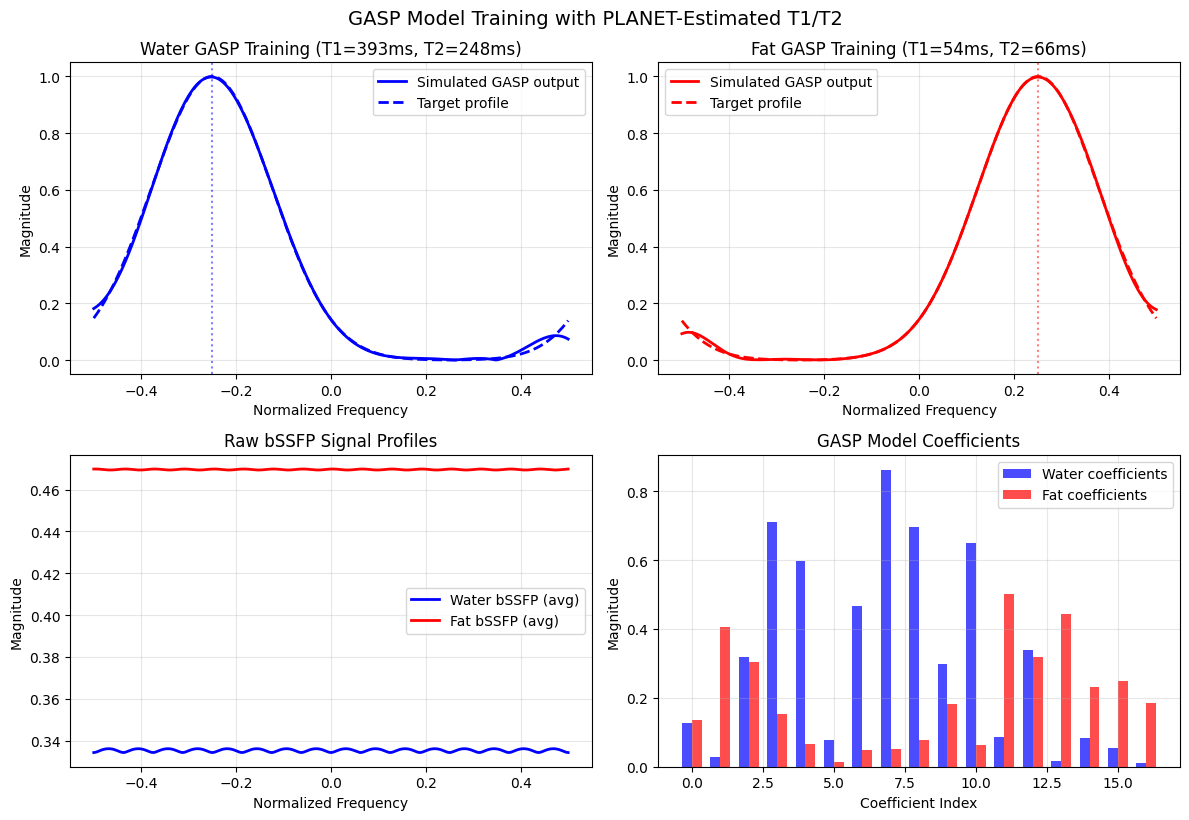


Training complete!

The trained coefficients (A_water_sim, A_fat_sim) can be used
to apply GASP to new data with similar tissue properties.


In [96]:
# Visualize the simulated spectral profiles and target profiles
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Normalize frequency axis to match target profile
norm_freq = np.linspace(-0.5, 0.5, n_freq_points)

# Water simulation
axes[0, 0].plot(norm_freq, np.abs(water_recon_sim).flatten(), 'b-', label='Simulated GASP output', linewidth=2)
axes[0, 0].plot(np.linspace(-0.5, 0.5, len(D_water)), D_water, 'b--', label='Target profile', linewidth=2)
axes[0, 0].set_xlabel('Normalized Frequency')
axes[0, 0].set_ylabel('Magnitude')
axes[0, 0].set_title(f'Water GASP Training (T1={train_T1_water*1e3:.0f}ms, T2={train_T2_water*1e3:.0f}ms)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(-0.25, color='b', linestyle=':', alpha=0.5)

# Fat simulation
axes[0, 1].plot(norm_freq, np.abs(fat_recon_sim).flatten(), 'r-', label='Simulated GASP output', linewidth=2)
axes[0, 1].plot(np.linspace(-0.5, 0.5, len(D_fat)), D_fat, 'r--', label='Target profile', linewidth=2)
axes[0, 1].set_xlabel('Normalized Frequency')
axes[0, 1].set_ylabel('Magnitude')
axes[0, 1].set_title(f'Fat GASP Training (T1={train_T1_fat*1e3:.0f}ms, T2={train_T2_fat*1e3:.0f}ms)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(0.25, color='r', linestyle=':', alpha=0.5)

# Show raw bSSFP magnitude profiles
axes[1, 0].plot(norm_freq, np.mean(np.abs(water_signal), axis=-1), 'b-', linewidth=2, label='Water bSSFP (avg)')
axes[1, 0].plot(norm_freq, np.mean(np.abs(fat_signal), axis=-1), 'r-', linewidth=2, label='Fat bSSFP (avg)')
axes[1, 0].set_xlabel('Normalized Frequency')
axes[1, 0].set_ylabel('Magnitude')
axes[1, 0].set_title('Raw bSSFP Signal Profiles')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Show coefficient magnitudes
coeff_idx = np.arange(len(A_water_sim))
width = 0.35
axes[1, 1].bar(coeff_idx - width/2, np.abs(A_water_sim), width, label='Water coefficients', color='blue', alpha=0.7)
axes[1, 1].bar(coeff_idx + width/2, np.abs(A_fat_sim), width, label='Fat coefficients', color='red', alpha=0.7)
axes[1, 1].set_xlabel('Coefficient Index')
axes[1, 1].set_ylabel('Magnitude')
axes[1, 1].set_title('GASP Model Coefficients')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('GASP Model Training with PLANET-Estimated T1/T2', fontsize=14, y=1.02)
plt.show()

print("\n" + "=" * 50)
print("Training complete!")
print("=" * 50)
print("\nThe trained coefficients (A_water_sim, A_fat_sim) can be used")
print("to apply GASP to new data with similar tissue properties.")